# 🎓 Student Performance Predictor — Model Testing
**Model:** Random Forest Regressor  
**Target:** Predicted End-Semester Marks (0–50)  
**Metrics:** MAE · RMSE · R² Score  

## 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 2. Load Dataset

In [3]:
df = pd.read_csv("student_performance_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 13)


,Attendance,Study_Hours,Previous_CGPA,Internal_Marks,Midsem_Marks,Backlogs,Assignment_Completion,Class_Participation,Age,Sex,Extra_Curricular,Late_Night_Entry,Endsem_Marks
0,62.472407,3.736408,8.379990,14.572169,12.472801,0,96.612366,1,25,0,0,5,28.364189
1,97.042858,3.329121,5.107072,11.889387,7.370444,3,78.635036,5,24,0,0,5,23.661872
2,83.919637,1.761539,6.079838,19.467478,8.158981,5,94.222079,4,22,2,0,4,13.495336
3,75.919509,6.072667,7.979684,8.284677,9.516778,1,85.076487,2,24,2,1,5,30.782311
4,49.361118,4.766242,6.892536,13.817846,10.091333,1,60.753489,5,22,0,1,1,30.333454


## 3. Target Distribution Check

Min End-Sem Marks : 0.2216
Max End-Sem Marks : 50.0
Mean End-Sem Marks: 24.7458
Std Dev           : 8.4559


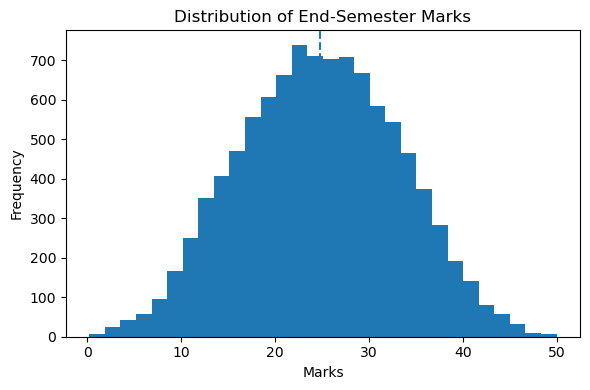

In [4]:
# Basic stats
print("Min End-Sem Marks :", round(df["Endsem_Marks"].min(), 4))
print("Max End-Sem Marks :", round(df["Endsem_Marks"].max(), 4))
print("Mean End-Sem Marks:", round(df["Endsem_Marks"].mean(), 4))
print("Std Dev           :", round(df["Endsem_Marks"].std(), 4))

# SIMPLE DISTRIBUTION PLOT
plt.figure(figsize=(6,4))

plt.hist(df["Endsem_Marks"], bins=30)
plt.axvline(df["Endsem_Marks"].mean(), linestyle='--')  # mean line

plt.title("Distribution of End-Semester Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 4. Train / Test Split & Scaling

In [5]:
X = df.drop("Endsem_Marks", axis=1)
y = df["Endsem_Marks"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 8000
Testing samples  : 2000
Features         : 12


## 5. Train Random Forest Regressor

In [6]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42
)
model.fit(X_train_scaled, y_train)
print("✅ Random Forest model trained successfully")

✅ Random Forest model trained successfully


## 6. Evaluation Metrics — MAE · RMSE · R²

In [7]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test  = model.predict(X_test_scaled)

# Test metrics 
mae  = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2   = r2_score(y_test, y_pred_test)

# Train metrics (to check overfitting) ─────────────────────────────────────
mae_tr  = mean_absolute_error(y_train, y_pred_train)
rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_tr   = r2_score(y_train, y_pred_train)

print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"{'Metric':<12} {'Train':>10} {'Test':>10}")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"{'MAE':<12} {mae_tr:>10.4f} {mae:>10.4f}")
print(f"{'RMSE':<12} {rmse_tr:>10.4f} {rmse:>10.4f}")
print(f"{'R² Score':<12} {r2_tr:>10.4f} {r2:>10.4f}")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Metric            Train       Test
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MAE              0.7503     1.9390
RMSE             0.9440     2.4455
R² Score         0.9875     0.9166
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 7. Visualisations


📊 Model Performance:
MAE  : 1.94
RMSE : 2.45
R²   : 0.9166


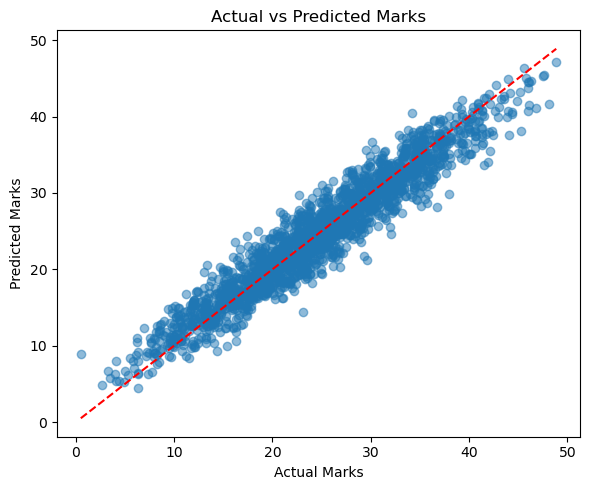

In [8]:
# Predictions
y_pred = model.predict(X_test_scaled)

# Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("\n📊 Model Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")

plt.tight_layout()
plt.show()